# S05 · Время доставки: обучение и проверка

9 октября 2026. Прогноз полного времени доставки: 48 синтетических заказов, 36 train и 12 test. Обучаем, проверяем и прогнозируем новый заказ.

Начните с **Restart Kernel** и выполняйте ячейки сверху вниз. C01, C02 и далее обозначают ячейки. Полная версия с готовыми решениями.

[Описание таблиц и условий](../../data/DELIVERY-README.md).

## C01 · Подготовка

Импорты и путь к локальным CSV-файлам.

In [1]:
# S05-C01
import csv
from math import sqrt
from pathlib import Path

import matplotlib.pyplot as plt

data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("../../data")
if not data_dir.exists():
    data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("starter/data")
print("Данные:", data_dir)


Данные: ../../data


## C02 · Читаем заказы

48 синтетических заказов: 36 train и 12 test. `train_x` содержит расстояния в километрах, `train_y` время доставки в минутах. Одинаковый индекс соответствует одному заказу.

In [2]:
# S05-C02
with (data_dir / "delivery-orders-synthetic.csv").open() as file:
    rows = list(csv.DictReader(file))
train_rows = []
test_rows = []
for row in rows:
    if row["split"] == "train":
        train_rows.append(row)
    else:
        test_rows.append(row)
train_x = []
train_y = []
for row in train_rows:
    train_x.append(float(row["distance_km"]))
    train_y.append(float(row["delivery_minutes"]))
print("Train:", len(train_rows), "Test:", len(test_rows))


Train: 36 Test: 12


## C03 · Точки до обучения

Каждая точка соответствует заказу. По горизонтали расстояние, по вертикали время доставки.

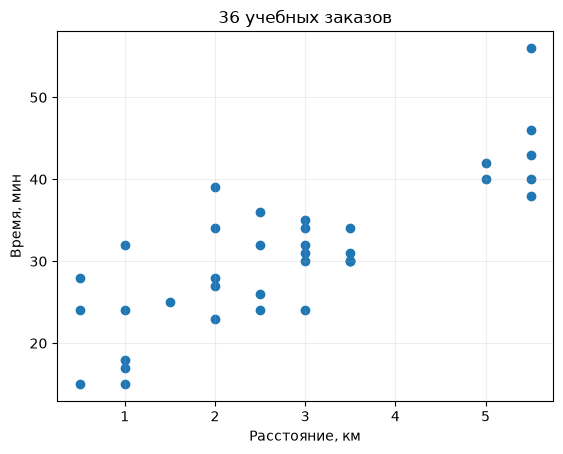

In [3]:
# S05-C03
plt.scatter(train_x, train_y)
plt.xlabel("Расстояние, км")
plt.ylabel("Время, мин")
plt.title("36 учебных заказов")
plt.grid(alpha=0.2)
plt.show()


## C04 · Среднее как простой прогноз

Задание 1. Вычислите среднее время по 36 обучающим заказам: сумма времён / число заказов. Постоянная модель выдаёт это значение для любого расстояния.

In [4]:
# S05-C04
total_time = 0.0
for time_value in train_y:
    total_time = total_time + time_value
mean_train_time = total_time / len(train_y)
print("Постоянный прогноз, мин:", mean_train_time)


Постоянный прогноз, мин: 30.916666666666668


## C05 · Три заказа для ручного шага

D01-D03: $x=[1,2,3]$, $y=[18,27,24]$. При $w=0$, $b=20$ прогноз равен 20 минутам. Ошибка $e=\hat y-y$.

In [5]:
# S05-C05
tiny_x = train_x[:3]
tiny_y = train_y[:3]
w = 0.0
b = 20.0
for i in range(len(tiny_x)):
    prediction = w * tiny_x[i] + b
    error = prediction - tiny_y[i]
    print(tiny_x[i], tiny_y[i], prediction, error, error * tiny_x[i], error ** 2)


1.0 18.0 20.0 2.0 2.0 4.0
2.0 27.0 20.0 -7.0 -14.0 49.0
3.0 24.0 20.0 -4.0 -12.0 16.0


## C06 · Функция MSE

$\mathrm{MSE}=\frac1n\sum_i(wx_i+b-y_i)^2$. Функция вычисляет потерю при заданных параметрах.

In [6]:
# S05-C06
def mean_squared_error(x_values, y_values, w, b):
    total_squared_error = 0.0
    for i in range(len(x_values)):
        prediction = w * x_values[i] + b
        error = prediction - y_values[i]
        total_squared_error = total_squared_error + error ** 2
    return total_squared_error / len(x_values)
print("MSE до шага:", mean_squared_error(tiny_x, tiny_y, 0, 20))


MSE до шага: 23.0


## C07 · Две производные

Задание 2. Восстановите накопление суммы $e_ix_i$. Производные: $g_w=\frac2n\sum_i e_ix_i$, $g_b=\frac2n\sum_i e_i$.

In [7]:
# S05-C07
def gradients(x_values, y_values, w, b):
    sum_error_x = 0.0
    sum_error = 0.0
    for i in range(len(x_values)):
        prediction = w * x_values[i] + b
        error = prediction - y_values[i]
        sum_error_x = sum_error_x + error * x_values[i]
        sum_error = sum_error + error
    dw = 2 * sum_error_x / len(x_values)
    db = 2 * sum_error / len(x_values)
    return dw, db
print("Градиент:", gradients(tiny_x, tiny_y, 0, 20))


Градиент: (-16.0, -6.0)


## C08 · Первый шаг

Один шаг: $w_{new}=w-\eta g_w$, $b_{new}=b-\eta g_b$, $\eta=0.1$. Обе производные вычисляются до изменения параметров.

In [8]:
# S05-C08
w = 0.0
b = 20.0
learning_rate = 0.1
before = mean_squared_error(tiny_x, tiny_y, w, b)
dw, db = gradients(tiny_x, tiny_y, w, b)
w = w - learning_rate * dw
b = b - learning_rate * db
after = mean_squared_error(tiny_x, tiny_y, w, b)
print("w, b:", w, b)
print("MSE до и после:", before, after)


w, b: 1.6 20.6
MSE до и после: 23.0 9.946666666666674


## C09 · Обучение на 36 заказах

Задание 3. Восстановите обновление веса. Обучение на 36 заказах: начальные параметры нулевые, шаг 0.03, число итераций 1500.

In [9]:
# S05-C09
w = 0.0
b = 0.0
learning_rate = 0.03
loss_history = [mean_squared_error(train_x, train_y, w, b)]
for step in range(1500):
    dw, db = gradients(train_x, train_y, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    loss_history.append(mean_squared_error(train_x, train_y, w, b))
print("Параметры:", w, b)
print("MSE train:", loss_history[-1])


Параметры: 4.50919059694756 18.26588192605254
MSE train: 26.25847844781254


## C10 · История потери

История содержит потерю до обучения и после каждого шага: всего 1501 значение. Вертикальная шкала логарифмическая.

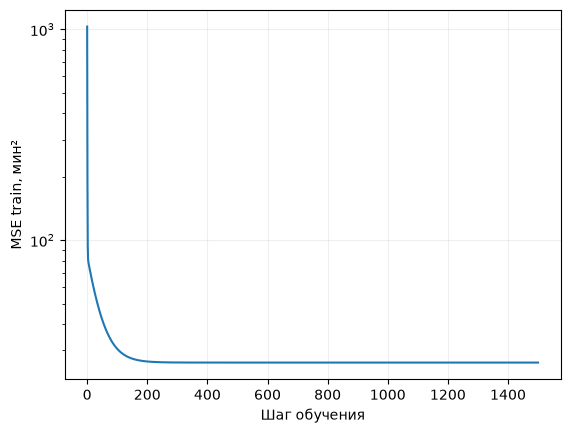

In [10]:
# S05-C10
plt.plot(loss_history)
plt.xlabel("Шаг обучения")
plt.ylabel("MSE train, мин²")
plt.yscale("log")
plt.grid(alpha=0.2)
plt.show()


## C11 · Шаг обучения и результат

Три запуска на одних обучающих заказах: шаги 0.003, 0.03 и 0.1. Каждый запуск начинается с нулевых параметров и выполняет 30 итераций.

In [11]:
# S05-C11
rate_results = []
for rate in [0.003, 0.03, 0.1]:
    trial_w = 0.0
    trial_b = 0.0
    for step in range(30):
        dw, db = gradients(train_x, train_y, trial_w, trial_b)
        trial_w = trial_w - rate * dw
        trial_b = trial_b - rate * db
    trial_loss = mean_squared_error(train_x, train_y, trial_w, trial_b)
    rate_results.append([rate, trial_loss])
    print("Шаг и MSE после 30 итераций:", rate, trial_loss)


Шаг и MSE после 30 итераций: 0.003 95.4611181544124
Шаг и MSE после 30 итераций: 0.03 52.76941553183528
Шаг и MSE после 30 итераций: 0.1 85417269.89371574


## C12 · Прямая и среднее

Прогноз среднего и обученная прямая на 36 train-заказах.

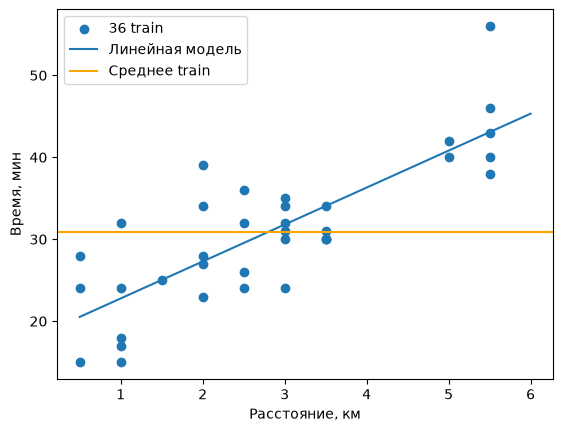

In [12]:
# S05-C12
line_x = [0.5, 6.0]
line_y = [w * line_x[0] + b, w * line_x[1] + b]
plt.scatter(train_x, train_y, label="36 train")
plt.plot(line_x, line_y, label="Линейная модель")
plt.axhline(mean_train_time, color="orange", label="Среднее train")
plt.xlabel("Расстояние, км")
plt.ylabel("Время, мин")
plt.legend()
plt.show()


## C13 · Проверка на новых заказах

Проверка на 12 test-заказах. $\mathrm{MAE}=\frac1n\sum_i|\hat y_i-y_i|$, $\mathrm{RMSE}=\sqrt{\frac1n\sum_i(\hat y_i-y_i)^2}$. Обе метрики измеряются в минутах.

In [13]:
# S05-C13
def error_metrics(actual, predictions):
    absolute_sum = 0.0
    squared_sum = 0.0
    for i in range(len(actual)):
        error = predictions[i] - actual[i]
        absolute_sum = absolute_sum + abs(error)
        squared_sum = squared_sum + error ** 2
    mae = absolute_sum / len(actual)
    mse = squared_sum / len(actual)
    rmse = sqrt(mse)
    return float(mae), rmse

test_y = []
model_predictions = []
baseline_predictions = []
for row in test_rows:
    distance = float(row["distance_km"])
    test_y.append(float(row["delivery_minutes"]))
    model_predictions.append(w * distance + b)
    baseline_predictions.append(mean_train_time)
print("Среднее, MAE и RMSE:", error_metrics(test_y, baseline_predictions))
print("Прямая, MAE и RMSE:", error_metrics(test_y, model_predictions))


Среднее, MAE и RMSE: (5.527777777777776, 7.507866245182818)
Прямая, MAE и RMSE: (5.578039357982486, 6.763841065214308)


## C14 · Прогноз нового заказа

Новый заказ: расстояние 2 км, до выхода 35 минут. Точечный прогноз времени и средняя ошибка на test не определяют вероятность успеть к сроку.

In [14]:
# S05-C14
new_distance = 2.0
new_prediction = w * new_distance + b
print("Прогноз, мин:", round(new_prediction, 1))


Прогноз, мин: 27.3


## Результат

Модель, ошибка на проверочных данных и прогноз для нового заказа или поездки. Все наблюдения синтетические.